# Variable sine wave oscillator

In [37]:
# We start with some imports
import matplotlib.pyplot as plt
import numpy as np

from engine import (
    TriangleOscillator, SawtoothOscillator, SineOscillator, SquareOscillator
)

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 10

figsize = (25, 6.25)
colors = "#323031", "#308E91", "#34369D", "#5E2A7E", "#5E2A7E", "#6F3384"

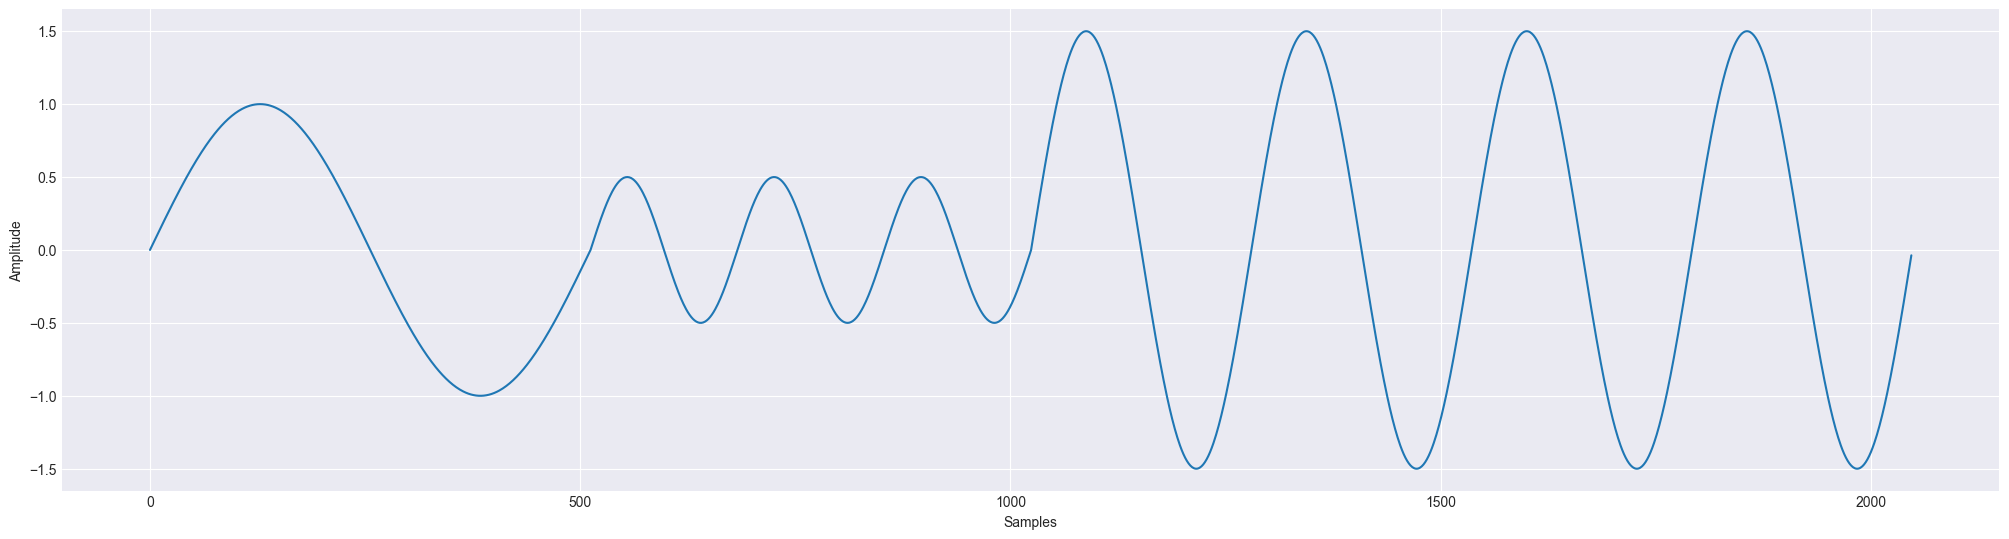

In [38]:
plt.figure(figsize=figsize)

osc = SineOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples1 = osc.get_samples(n=512)

# changing parameters of the oscillator and get additional samples
osc.frequency = 3
osc.amplitude = 0.5
samples2 = osc.get_samples(n=512)

osc.frequency = 2
osc.amplitude = 1.5
samples3 = osc.get_samples(n=1024)

plt.ylabel("Amplitude")
plt.xlabel("Samples")

plt.plot(np.concatenate([samples1, samples2, samples3]))
plt.show()

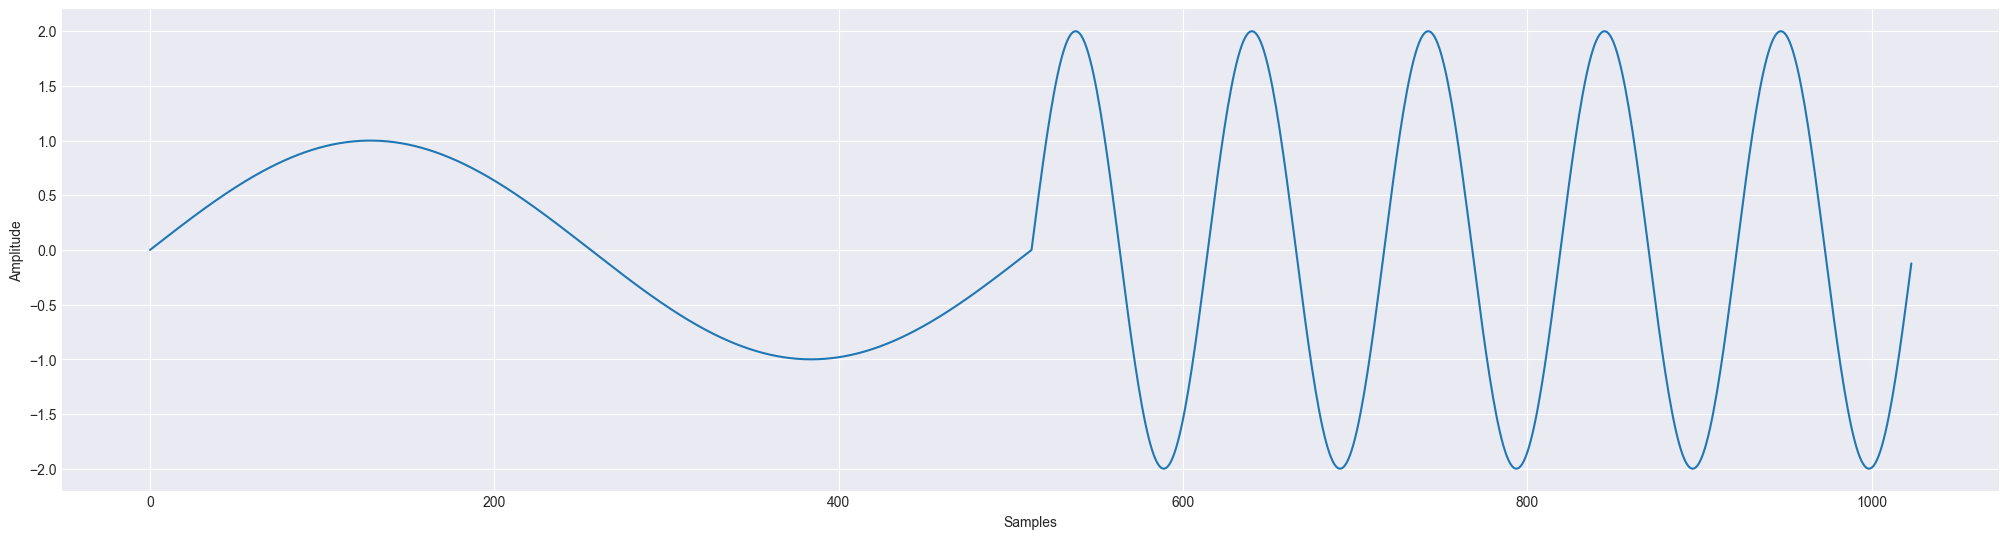

In [39]:
plt.figure(figsize=figsize)

osc2 = SineOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples2_1 = osc2.get_samples(n=512)
osc2.amplitude = 2
osc2.frequency = 5
osc2.phase = 0
samples2_2 = osc2.get_samples(n=512)

plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(np.concatenate([samples2_1, samples2_2]))
plt.show()

## Variable square wave oscillator

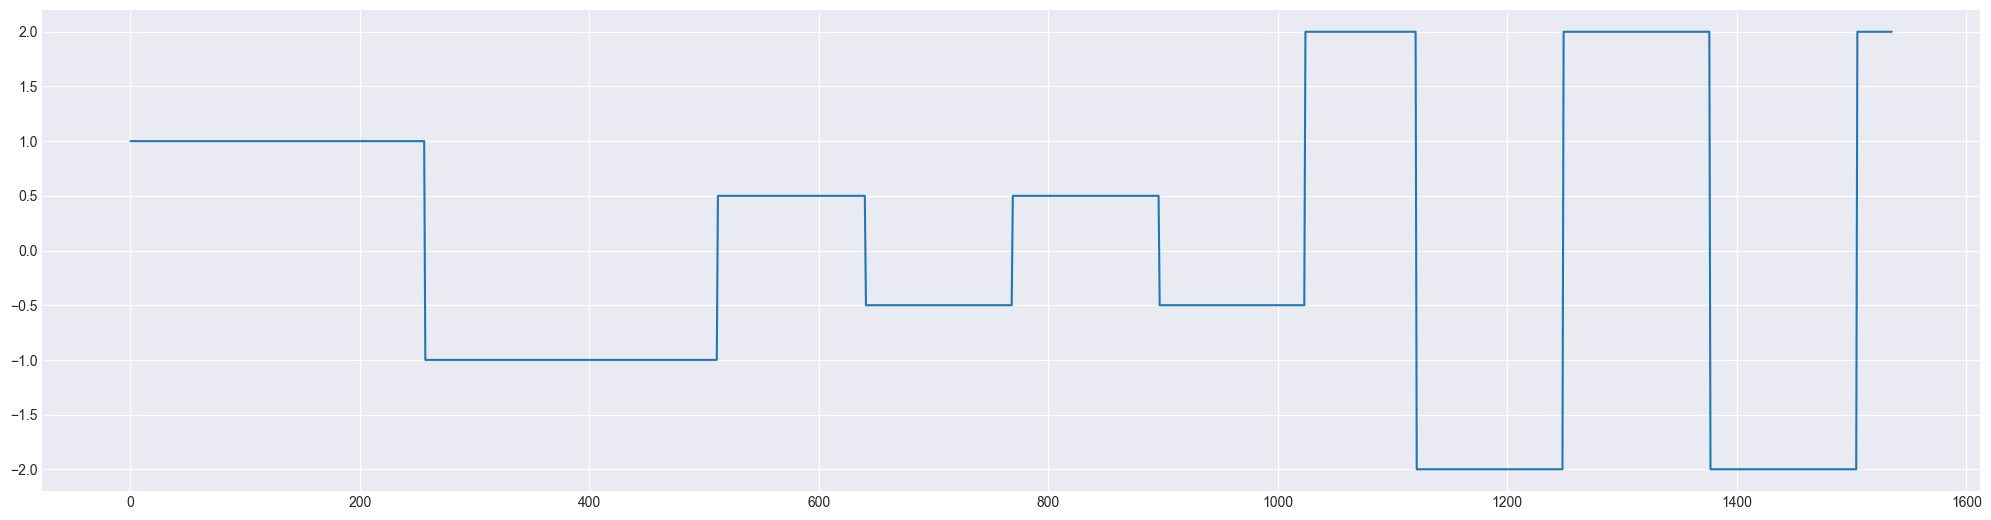

In [40]:
plt.figure(figsize=figsize)

osc = SquareOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)

# Get 512 samples from the oscillator
samples1 = osc.get_samples(n=512)
osc.frequency = 2
osc.amplitude = 0.5
samples2 = osc.get_samples(n=512)
osc.amplitude = 2
osc.phase = 45
samples3 = osc.get_samples(n=512)
samples = np.concatenate([samples1, samples2, samples3])
plt.plot(samples)
plt.show()

## Variable Square wave frequency sweep

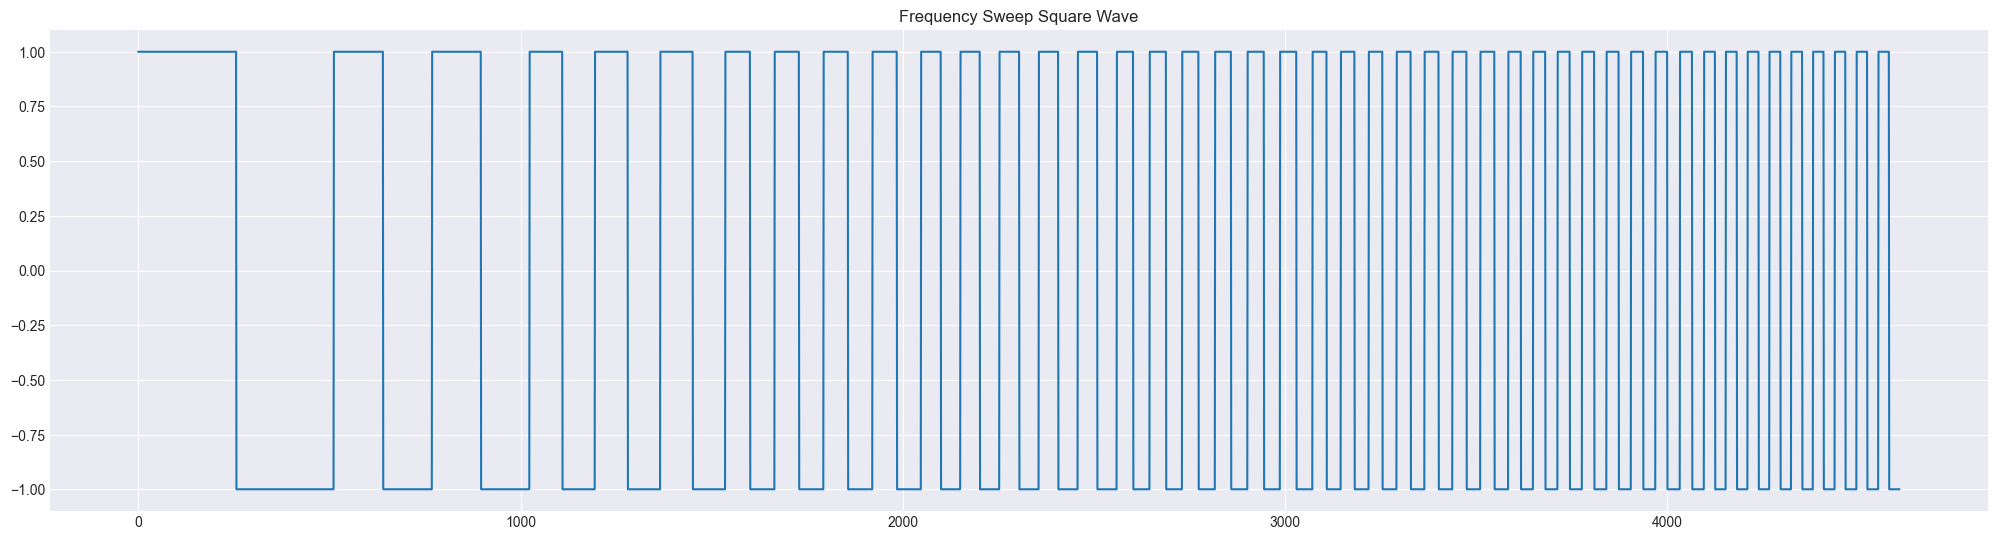

In [41]:
def plot_osc(oscillator, name=""):
    _ = plt.figure(figsize=(25, 6.25))
    plt.title(f"Frequency Sweep {name} Wave")
    oscillator = oscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)

    s = []
    for f in range(1, 10):
        oscillator.frequency = f
        s.append(oscillator.get_samples(n=512))

    plt.plot(np.concatenate(s))


plot_osc(SquareOscillator, "Square")

## Triangle

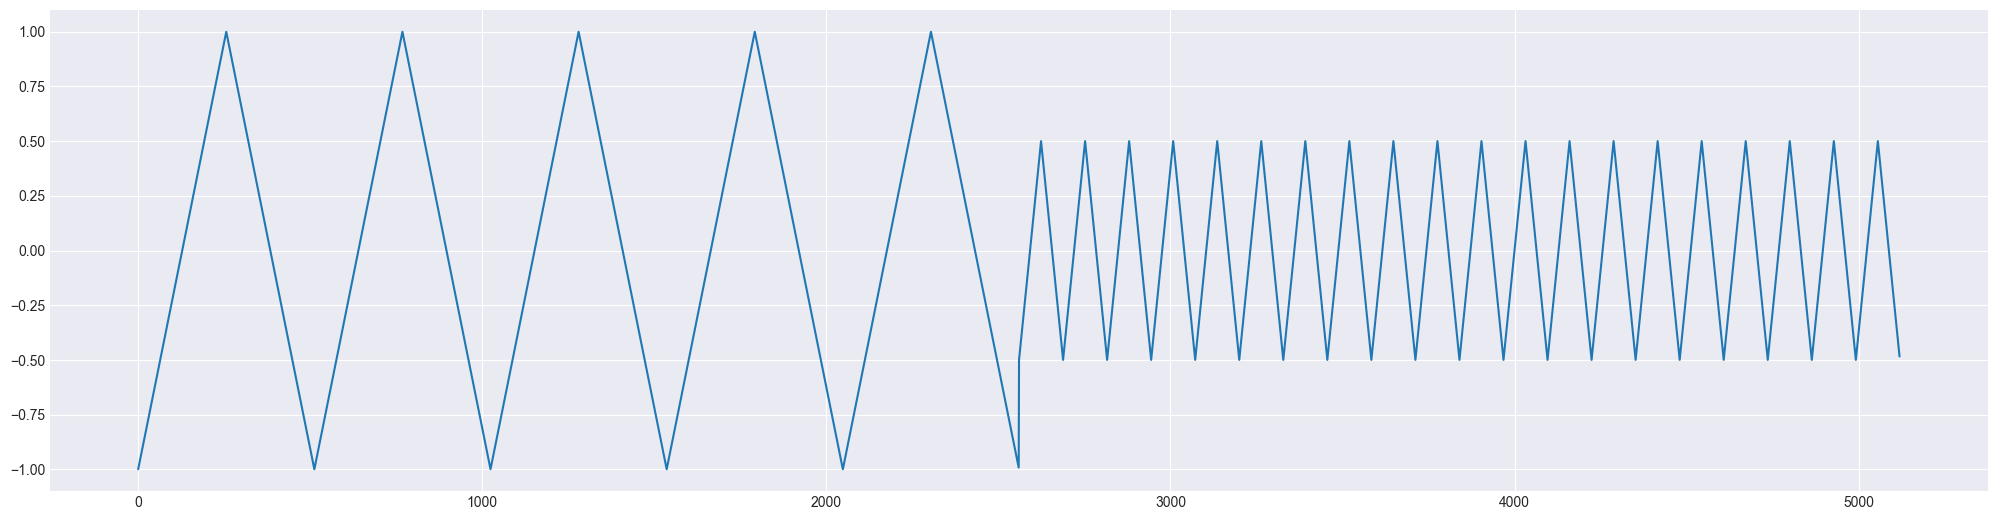

In [42]:
plt.figure(figsize=figsize)

osc = TriangleOscillator(frequency=1, amplitude=1, phase=0, sample_rate=512)
samples1 = osc.get_samples(n=512 * 5)

osc.frequency = 4
osc.amplitude = 0.5
samples2 = osc.get_samples(n=512 * 5)

plt.plot(np.concatenate([samples1, samples2]))
plt.show()

## Sawtooth - Random frequency and amplitude changes

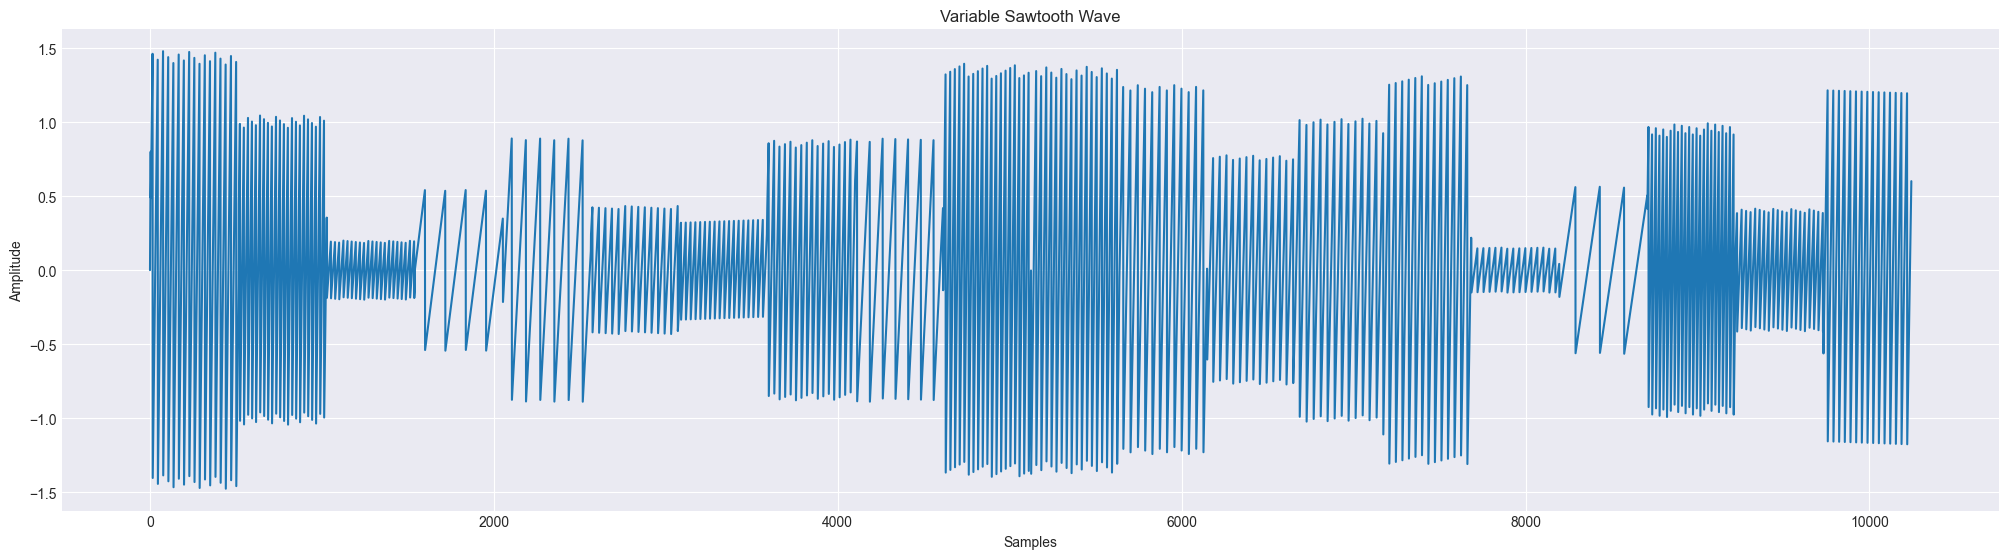

In [43]:
osc = SawtoothOscillator(frequency=10, amplitude=1, phase=0, sample_rate=100)
samples = osc.get_samples(n=5)

# Generate random variations of frequency and amplitude
for i in range(20):
    osc.frequency = np.random.uniform(0.1, 5)
    osc.amplitude = np.random.uniform(0.1, 1.5)
    samples = np.concatenate([samples, osc.get_samples(n=512)])

_, ax = plt.subplots(figsize=figsize)
plt.title("Variable Sawtooth Wave")
plt.ylabel("Amplitude")
plt.xlabel("Samples")
plt.plot(samples)
plt.show()